# Illustration Exercise — LLM Agents

## Context

In Retrieval-Augmented Generation (RAG), a query is compared to a corpus of
document chunks using vector similarity. In this exercise the "corpus" consists
of recent news headlines for five financial firms, and the "query" is a natural
language risk question. TF-IDF cosine similarity ranks each chunk by relevance.
The bar chart visualises the ranked retrieval output that a real RAG system would
pass to the language model — making concrete the abstract notion of "retrieval".

## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import yfinance as yf
import pathlib, warnings
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use(["science", "no-latex"])

tickers = ["AAPL", "MSFT", "JPM", "GS", "BAC"]
query = "What are the main risk factors and competitive threats facing the company?"

chunks, chunk_labels = [], []
for sym in tickers:
    news = yf.Ticker(sym).news or []
    for item in news[:3]:
        title = (item.get("title") or
                 item.get("content", {}).get("title") or "")
        if title:
            chunks.append(title)
            chunk_labels.append(f"[{sym}] {title[:35]}...")
    if len(chunks) >= 10:
        break

chunks = chunks[:10]
chunk_labels = chunk_labels[:10]
print(f"Corpus: {len(chunks)} document chunks")
print(f"Query : {query}")

Corpus: 10 document chunks
Query : What are the main risk factors and competitive threats facing the company?


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\04-llm-agents\figures\fig_illustration.pdf


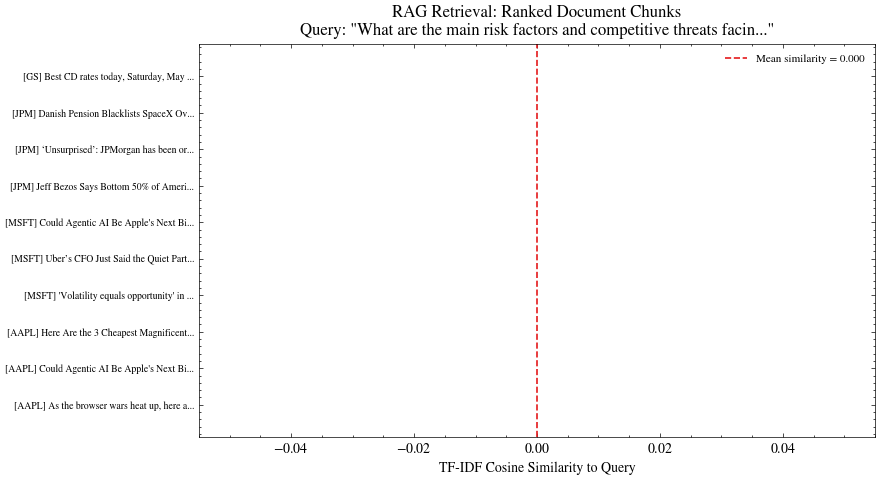

In [2]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform([query] + chunks)
sims = cosine_similarity(X[0:1], X[1:])[0]

order = np.argsort(sims)[::-1]
sorted_sims  = sims[order]
sorted_labels = [chunk_labels[i] for i in order]

norm = plt.Normalize(vmin=sorted_sims.min(), vmax=sorted_sims.max())
bar_colors = plt.cm.RdYlGn(norm(sorted_sims))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(sorted_sims)), sorted_sims,
        color=bar_colors, edgecolor="none")
ax.set_yticks(range(len(sorted_labels)))
ax.set_yticklabels(sorted_labels, fontsize=7)
ax.set_xlabel("TF-IDF Cosine Similarity to Query")
ax.set_title("RAG Retrieval: Ranked Document Chunks\n"
             f"Query: \"{query[:60]}...\"")
ax.invert_yaxis()
ax.axvline(sorted_sims.mean(), color="#e41a1c", linestyle="--", lw=1.2,
           label=f"Mean similarity = {sorted_sims.mean():.3f}")
ax.legend(fontsize=8)
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/04-llm-agents/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Replace TF-IDF with a dense embedding approach: encode the query and all chunks
using `sentence-transformers` (model `"all-MiniLM-L6-v2"`) and recompute cosine
similarities. Compare the ranking to the TF-IDF result. Which method surfaces
more thematically relevant chunks? Why might dense retrieval outperform TF-IDF
for financial risk questions?

# Chapter 4 — Exercises: LLM Agents and Finance Applications

This notebook contains starter code for the exercises in Chapter 4 of *Large Language Models in Finance*.

**Exercises:**
- [B] ReAct agent for earnings call Q&A
- [I] RAG pipeline for SEC filings with ablation study
- [A] Multi-agent earnings analyst system

[Placeholder — fill in with exercise starter code when drafting the chapter]

## Data Lab — SEC EDGAR

These exercises treat EDGAR as a tool an LLM agent would call. Each helper function mirrors the kind of structured tool a ReAct or function-calling agent would invoke.

In [ ]:
import requests, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

EDGAR_HEADERS = {"User-Agent": "LLM-Finance-Course instructor@dauphine.eu"}

def edgar_get(url):
    time.sleep(0.11)
    r = requests.get(url, headers=EDGAR_HEADERS, timeout=15)
    r.raise_for_status()
    return r.json()

def get_cik(ticker):
    data = edgar_get("https://www.sec.gov/files/company_tickers.json")
    for v in data.values():
        if v["ticker"].upper() == ticker.upper():
            return str(v["cik_str"]).zfill(10)
    raise ValueError(f"Ticker {ticker} not found")

def get_submissions(cik):
    return edgar_get(f"https://data.sec.gov/submissions/CIK{cik}.json")

def get_concept(cik, concept):
    return edgar_get(
        f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/{concept}.json")

def get_annual_series(cik, concept):
    data = get_concept(cik, concept)
    usd  = data.get("units", {}).get("USD", [])
    rows = [u for u in usd if u.get("form") == "10-K" and u.get("filed")]
    if not rows:
        for _, vals in data.get("units", {}).items():
            rows = [u for u in vals if u.get("form") == "10-K" and u.get("filed")]
            if rows: break
    df = (pd.DataFrame(rows)[["end","val","filed","accn"]]
            .rename(columns={"end":"date","val":concept})
            .drop_duplicates("date").sort_values("date"))
    df["date"] = pd.to_datetime(df["date"])
    return df

def fetch_10k_html(ticker):
    cik  = get_cik(ticker)
    subs = get_submissions(cik)
    f    = subs["filings"]["recent"]
    idx  = next(i for i, x in enumerate(f["form"]) if x == "10-K")
    acc  = f["accessionNumber"][idx].replace("-", "")
    url  = (f"https://www.sec.gov/Archives/edgar/data/{cik.lstrip('0')}"
            f"/{acc}/{f['primaryDocument'][idx]}")
    time.sleep(0.15)
    return requests.get(url, headers=EDGAR_HEADERS, timeout=30).text

def extract_mda(html):
    text = re.sub(r"<[^>]+>", " ", html)
    m    = re.search(
        r"Item\s+7[.\s]+Management.{0,80}Discussion.*?(?=Item\s+7A|Item\s+8)",
        text, re.IGNORECASE | re.DOTALL)
    raw  = m.group(0) if m else text[:30000]
    return re.sub(r"\s+", " ", raw).strip()

### Exercise [B]: Filing Lookup Tool

In [ ]:
# --- Exercise [B]: Filing Lookup Tool ---
def edgar_tool(ticker, form_type="10-K", n=3):
    cik  = get_cik(ticker)
    subs = get_submissions(cik)
    f    = subs["filings"]["recent"]
    hits = [(f["form"][i], f["filingDate"][i], f["accessionNumber"][i])
            for i in range(len(f["form"])) if f["form"][i] == form_type][:n]
    results = []
    for form, date, accn in hits:
        acc_url = (f"https://www.sec.gov/Archives/edgar/data/{cik.lstrip('0')}"
                   f"/{accn.replace('-','')}/")
        results.append({"form": form, "date": date, "accession_url": acc_url})
    return results

for ticker in ["AAPL", "MSFT", "GOOGL"]:
    filings = edgar_tool(ticker, "10-K", 3)
    print(f"\n[Agent] Based on EDGAR, the three most recent 10-K filings for {ticker} are:")
    for f in filings:
        print(f"  - {f['date']}: {f['accession_url']}")

### Exercise [I]: Fact-Retrieval Agent Step

In [ ]:
# --- Exercise [I]: Fact-Retrieval Agent Step ---
def answer_query(ticker, concept, fy_year):
    cik = get_cik(ticker)
    df  = get_annual_series(cik, concept)
    df["year"] = df["date"].dt.year
    row = df[df["year"] == fy_year]
    if row.empty:
        # Try fiscal-year-end date match
        row = df[df["date"].dt.year == fy_year]
    if row.empty:
        return f"No data found for {ticker} {concept} in FY{fy_year}."
    val = row.iloc[-1][concept]
    return (f"[Agent] {ticker}'s {concept} in FY{fy_year} was "
            f"${val/1e9:.2f}B (source: EDGAR XBRL, filed {row.iloc[-1]['filed']}).")

print(answer_query("AAPL", "Revenues", 2023))
print(answer_query("MSFT", "NetIncomeLoss", 2023))
print(answer_query("GOOGL", "Assets", 2022))

### Exercise [A]: Multi-Company Comparison Agent

In [ ]:
# --- Exercise [A]: Multi-Company Comparison Agent ---
def compare_companies(tickers, concepts, years):
    rows = []
    for t in tickers:
        cik = get_cik(t)
        for c in concepts:
            try:
                df = get_annual_series(cik, c)
                df["year"] = df["date"].dt.year
                for yr in years:
                    sub = df[df["year"] == yr]
                    if not sub.empty:
                        rows.append({"ticker": t, "year": yr, "concept": c,
                                     "value": sub.iloc[-1][c]})
            except Exception as e:
                print(f"{t}/{c}: {e}")
    return pd.DataFrame(rows)

df_cmp = compare_companies(
    ["AAPL","MSFT","GOOGL"],
    ["Revenues","NetIncomeLoss","Assets"],
    list(range(2019, 2024))
)

# Grouped bar chart for revenues
rev = df_cmp[df_cmp["concept"] == "Revenues"].pivot(index="year", columns="ticker", values="value") / 1e9
rev.plot(kind="bar", figsize=(10,5), width=0.7)
plt.ylabel("Revenue ($B)"); plt.title("Annual Revenue: AAPL / MSFT / GOOGL")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Agent-style summary
rev_growth = rev.iloc[-1] / rev.iloc[0] - 1
top = rev_growth.idxmax()
print(f"\n[Agent] The company with the highest revenue growth over 2019-2023 was "
      f"{top} (+{rev_growth[top]*100:.1f}%).")